# E-Commerce Statistical Distribution Analysis Project
Dataset and analysis notebook for the assignment shown in the uploaded images.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox, zscore

df = pd.read_csv('ecommerce_transactions_dataset.csv')
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,TXN_0000001,CUST_01127,1162.40,2024-06-06,4,West,Success
1,TXN_0000002,CUST_00861,882.07,2024-10-04,4,North,Success
2,TXN_0000003,CUST_01131,5281.28,2024-07-21,8,West,Success
3,TXN_0000004,CUST_01096,1398.36,2024-03-06,3,South,Success
4,TXN_0000005,CUST_01045,2287.15,2024-04-17,5,East,Fail


## Part A - Theory
Fill in the theoretical answers from your report.


# Part A – Theoretical Foundation

## 1. What is Statistical Distribution?
A statistical distribution describes how values of a variable are spread across possible outcomes. It shows the probability of occurrence of different values and helps analysts understand patterns, variability, and uncertainty in data.

## 2. What is a Q-Q Plot and why is it used?
A Quantile-Quantile (Q-Q) Plot compares the quantiles of a dataset with the quantiles of a theoretical distribution (usually Normal). If points lie close to a straight line, the data follows the reference distribution. It is used to assess normality and detect skewness, outliers, and heavy tails.

## 3. Difference between Discrete and Continuous Distributions
Discrete distributions model countable values (e.g., number of transactions). Examples: Bernoulli, Binomial, Poisson.
Continuous distributions model measurable values (e.g., transaction amount). Examples: Normal, Log-Normal, Exponential.

## 4. What is Bernoulli Distribution?
A Bernoulli distribution models a single trial with two possible outcomes: Success (1) or Failure (0). The probability of success is p and failure is 1-p.

## 5. What is Binomial Distribution?
A Binomial distribution models the number of successes in n independent Bernoulli trials with probability p of success. It is commonly used for repeated yes/no events.

## 6. Explain Log-Normal Distribution
A variable follows a Log-Normal distribution if its logarithm follows a Normal distribution. It is positively skewed and commonly used for income, transaction amounts, and financial data.

## 7. Explain Power Law Distribution
A Power Law distribution has a heavy tail where a small number of observations account for a large proportion of the total value. Examples include wealth distribution, social-media followers, and some e-commerce purchases.

## 8. What is Box-Cox Transform?
The Box-Cox transformation is a family of power transformations used to reduce skewness, stabilize variance, and make data more normally distributed for statistical modeling.

## 9. Explain Poisson Distribution with an Example
The Poisson distribution models the number of events occurring in a fixed interval of time or space. Example: Number of purchases made on an e-commerce platform per hour.

## 10. What is Z-score Probability?
A Z-score measures how many standard deviations a value is from the mean.
Z = (X - μ) / σ
It is used to calculate probabilities and identify unusual observations.

## 11. Differentiate PDF and CDF
PDF (Probability Density Function):
- Describes the relative likelihood of a continuous variable.
- Area under the curve equals probability.

CDF (Cumulative Distribution Function):
- Gives the probability that a variable is less than or equal to a specific value.
- Values range from 0 to 1.


## Part B - Data Analysis Tasks

In [2]:
df['success_binary'] = (df['transaction_status']=='Success').astype(int)
p = df['success_binary'].mean()
print('Bernoulli p =', p)

Bernoulli p = 0.9284


In [3]:
lam = df['transaction_count'].mean()
print('Lambda:', lam)

Lambda: 5.019


In [4]:
shape, loc, scale = stats.lognorm.fit(df['transaction_amount'], floc=0)
print(shape, scale)

0.8006993771962249 2188.9626817809362


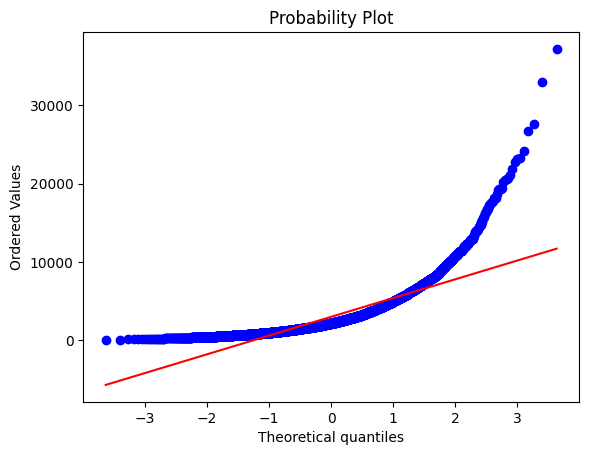

In [5]:
stats.probplot(df['transaction_amount'], dist='norm', plot=plt)
plt.show()

In [6]:
transformed, lam = boxcox(df['transaction_amount'])
print('Box-Cox Lambda:', lam)

Box-Cox Lambda: 0.008828612543316352


In [7]:
z = zscore(df['transaction_amount'])
print('Probability > 5000:', (df['transaction_amount'] > 5000).mean())

Probability > 5000: 0.156


In [8]:
x = np.linspace(df.transaction_amount.min(), df.transaction_amount.max(), 500)
shape, loc, scale = stats.lognorm.fit(df['transaction_amount'], floc=0)
pdf = stats.lognorm.pdf(x, shape, loc, scale)
cdf = stats.lognorm.cdf(x, shape, loc, scale)
